# Exploring the NIST Chemistry WebBook

The NIST Chemistry WebBook provides thermochemical, thermophysical, and ion energetics data compiled by NIST under the Standard Reference Data Program.  
[Visit NIST Chemistry WebBook](https://webbook.nist.gov/chemistry/)

If you have not explored the NIST Chemistry WebBook before, take some time to visit the link above and explore the site. Try the following exercises:

## 1. Search by name for "caffeine"
   * View the 3D structure by selecting the "Javascript" link
   * Examine the phase change data
   * Examine the IR spectrum data
   * Examine the UV-Vis spectrum data

## 2. Search by molecular formula for "C12H22O11"
   * Select "sucrose"
   * View the 3D structure by selecting the "Javascript" link
   * Examine the phase change data
   * Examine the IR spectrum data
   * Examine the UV-Vis spectrum data

## Before you begin

**Purpose.** Explore an example of mining boiling-point data and the difference between a live data-collection workflow and a prepared, reusable dataset.

**Normal path.** You may use the supplied Parquet files for this course. The live NIST collection cells are optional demonstrations: they depend on external websites, may change without notice, and can take from minutes to hours.

**Accessibility.** Each figure is followed by a caption that states its key interpretation; use the caption together with the plotted values and labels.


In [ ]:
from pathlib import Path
import os

# Prepared datasets can live beside this notebook, in the course data release,
# or in the directory specified by CHE8615_MODULE1_DATA_DIR.
MODULE_WORKING_DIR = Path.cwd().resolve()
COURSE_DIR = MODULE_WORKING_DIR.parent.parent if len(MODULE_WORKING_DIR.parents) >= 2 else MODULE_WORKING_DIR
DATA_DIRECTORIES = [MODULE_WORKING_DIR]
if os.environ.get("CHE8615_MODULE1_DATA_DIR"):
    DATA_DIRECTORIES.append(Path(os.environ["CHE8615_MODULE1_DATA_DIR"]).expanduser())
DATA_DIRECTORIES.append(COURSE_DIR / "8615_2026FS_parquet_files_release" / "01_Structure_to_Boiling_Point")

def data_path(filename: str) -> Path:
    for directory in DATA_DIRECTORIES:
        candidate = directory / filename
        if candidate.is_file():
            print(f"Using data file: {candidate}")
            return candidate
    locations = "\n  - ".join(str(directory) for directory in DATA_DIRECTORIES)
    raise FileNotFoundError(
        f"Could not find {filename}. Download the Module 1 Parquet files and place them "
        f"beside this notebook, or set CHE8615_MODULE1_DATA_DIR. Looked in:\n  - {locations}"
    )

def output_file(filename: str) -> Path:
    return MODULE_WORKING_DIR / filename


In [1]:
%matplotlib inline

In [ ]:
# NISTChemPy accesses NIST Chemistry WebBook records. It is already installed by environment.yml.
%pip install nistchempy==0.2.3

# Connecting to the NIST Chemistry WebBook

To connect with the NIST Chemistry WebBook, there is a Python package available that helps manage the connection to the API. You can find it here:  
[https://pypi.org/project/NistChemPy/](https://pypi.org/project/NistChemPy/)

## Installation Steps:

Download the software by opening a command prompt and following these steps:

1. Activate the "ci" environment for use in this class:

    conda activate ci
    

2. Install the `nistchempy` package with `pip`:

    pip install nistchempy==0.2.3
    

After completing these installation steps, you will need to **restart your kernel**.

Now that `nistchempy` is operational, let's take some time to explore the `nistchempy` environment.


In [ ]:
#You may also install inline in the current environment within a jupyter notebook like this:
%pip install nistchempy==0.2.3

<!-- che8615-clarity -->
### Start with a small data audit

**Purpose:** Connect to the WebBook interface and inspect what information is actually available.  
**Why it matters:** A model can only learn from fields that are present, sufficiently complete, and meaningful.  
**Key takeaway:** Before collecting thousands of records, verify the schema and ask which columns can support the scientific question.


In [3]:
# Example 1: Setup environment and examine a summary of all NIST data

import nistchempy as nist
df = nist.get_all_data()
display(df)

,ID,name,formula,mol_weight,inchi,inchi_key,cas_rn,mol2D,mol3D,cIR,...,cGC,cTG,cTC,cTP,cSO,cTR,cIE,cIC,cES,cDI
0,B100,iron oxide anion,FeO-,71.8450,<NA>,<NA>,<NA>,False,False,False,...,False,True,False,False,False,True,True,False,False,False
1,B1000,AsF3..Cl anion,AsClF3-,167.3700,<NA>,<NA>,<NA>,False,False,False,...,False,True,False,False,False,False,False,False,False,False
2,B1000000,AgH2-,AgH2-,109.8846,<NA>,<NA>,<NA>,False,False,False,...,False,False,False,False,False,False,False,False,True,False
3,B1000001,HAg(H2),AgH3,110.8920,<NA>,<NA>,<NA>,False,False,False,...,False,False,False,False,False,False,False,False,True,False
4,B1000002,AgNO+,AgNO+,137.8738,<NA>,<NA>,<NA>,False,False,False,...,False,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
129000,U99777,"Methyl 3-hydroxycholest-5-en-26-oate, TMS deri...",C31 H54 O3 Si,502.8442,InChI=1S/C31H54O3Si/c1-21(10-9-11-22(2)29(32)3...,DNXGNXYNSBCWGX-QBUYVTDMSA-N,<NA>,True,False,False,...,True,False,False,False,False,False,False,False,False,False
129001,U99830,"2-Methyl-3-oxovaleric acid, O,O'-bis(trimethyl...",C12 H26 O3 Si2,274.5040,"InChI=1S/C12H26O3Si2/c1-9-11(14-16(3,4)5)10(2)...",LXAIQDVPXKOIGO-KHPPLWFESA-N,<NA>,True,False,False,...,True,False,False,False,False,False,False,False,False,False
129002,U99942,3-Hydroxy-3-(4'-hydroxy-3'-methoxyphenyl)propi...,C19 H36 O5 Si3,428.7426,InChI=1S/C19H36O5Si3/c1-21-18-13-15(11-12-16(1...,QCMUGKOFXVYNCF-UHFFFAOYSA-N,<NA>,True,False,False,...,True,False,False,False,False,False,False,False,False,False
129003,U99947,"2-Propylpentanoic acid, 2,3,4,6-tetra(trimethy...",C26 H58 O7 Si4,595.0765,InChI=1S/C26H58O7Si4/c1-15-17-20(18-16-2)25(27...,OVXMRISJDUWFKB-UHFFFAOYSA-N,<NA>,True,False,False,...,True,False,False,False,False,False,False,False,False,False


# Boiling Point Prediction Based on Chemical Features

In this example, we want to predict the boiling point of a subset of molecules based on chemical features and the structure of the molecule.

The above list contains ions, heavy metals, etc., which we do not want to include in our training set.

Restricting the data can be done top-down using regular expressions on the molecular formula to mask the DataFrame, but enumerating all possible regular expressions may be arduous.


In [4]:
df.keys()

Index(['ID', 'name', 'formula', 'mol_weight', 'inchi', 'inchi_key', 'cas_rn',
       'mol2D', 'mol3D', 'cIR', 'cTZ', 'cMS', 'cUV', 'cGC', 'cTG', 'cTC',
       'cTP', 'cSO', 'cTR', 'cIE', 'cIC', 'cES', 'cDI'],
      dtype='object')

Note here that 'mol3D' information is included in this dataframe. 
We may want to use this 3D structure in our machine learning algoritms later.h

The keys 'cTG', 'cTC', etc. indicate whether each compound has specific data available on the NIST website. You can see a description of these keys by running the command:.


In [5]:
nist.print_search_parameters()

Units      :   Units for thermodynamic data, "SI" or "CAL" for calorie-based
MatchIso   :   Exactly match the specified isotopes (formula search only)
AllowOther :   Allow elements not specified in formula (formula search only)
AllowExtra :   Allow more atoms of elements in formula than specified (formula search only)
NoIon      :   Exclude ions from the search (formula search only)
cTG        :   Contains gas-phase thermodynamic data
cTC        :   Contains condensed-phase thermodynamic data
cTP        :   Contains phase-change thermodynamic data
cTR        :   Contains reaction thermodynamic data
cIE        :   Contains ion energetics thermodynamic data
cIC        :   Contains ion cluster thermodynamic data
cIR        :   Contains IR data
cTZ        :   Contains THz IR data
cMS        :   Contains MS data
cUV        :   Contains UV/Vis data
cGC        :   Contains gas chromatography data
cES        :   Contains vibrational and electronic energy levels
cDI        :   Contains constant

In [5]:
#In this example, we want to collect
a=df[(df['cTP']==True)]
display(a)
len(a)

,ID,name,formula,mol_weight,inchi,inchi_key,cas_rn,mol2D,mol3D,cIR,...,cGC,cTG,cTC,cTP,cSO,cTR,cIE,cIC,cES,cDI
4347,B2000040,Mg(neo-Pe)2,C10 H22 Mg,166.5867,<NA>,<NA>,<NA>,False,False,False,...,False,True,True,True,False,True,False,False,False,False
4350,B2000166,U(cotBu)2,C24 H32 U,558.5398,<NA>,<NA>,<NA>,False,False,False,...,False,True,True,True,False,False,False,False,False,False
4351,B2000167,U(OMe)6,C6 H18 O6 U,424.2324,<NA>,<NA>,<NA>,False,False,False,...,False,True,True,True,False,False,False,False,False,False
4352,B2000169,U(Cp)3(i-Bu),C19 H24 U,490.4228,<NA>,<NA>,<NA>,False,False,False,...,False,True,True,True,False,False,False,False,False,False
4353,B2000170,U(Cp)3(OBu),C19 H24 OU,506.4222,<NA>,<NA>,<NA>,False,False,False,...,False,True,True,True,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
66004,C999780,"2-Pentyne, 4,4-dimethyl-",C7 H12,96.1702,"InChI=1S/C7H12/c1-5-6-7(2,3)4/h1-4H3",FOALCTWKQSWRST-UHFFFAOYSA-N,999-78-0,True,True,True,...,True,True,False,True,False,False,True,False,False,False
66009,C99989,"1,4-Benzenediamine, N,N-dimethyl-",C8 H12 N2,136.1943,InChI=1S/C8H12N2/c1-10(2)8-5-3-7(9)4-6-8/h3-6H...,BZORFPDSXLZWJF-UHFFFAOYSA-N,99-98-9,True,True,False,...,True,False,False,True,False,False,True,False,False,False
66011,C99990,"Benzene, 1-methyl-4-nitro-",C7 H7 NO2,137.1360,InChI=1S/C7H7NO2/c1-6-2-4-7(5-3-6)8(9)10/h2-5H...,ZPTVNYMJQHSSEA-UHFFFAOYSA-N,99-99-0,True,True,True,...,True,True,True,True,True,True,True,True,False,False
66012,C999906,Ethanethioic acid S-tert-butyl ester,C6 H12 OS,132.2240,"InChI=1S/C6H12OS/c1-5(7)8-6(2,3)4/h1-4H3",PJFHXBBYLAVSLJ-UHFFFAOYSA-N,999-90-6,True,True,False,...,True,False,False,True,False,True,False,False,False,False


18899

In [6]:
#Another way of finding molecules that meet your needs is from the bottom-up by querying the NIST website programmatically
#This is why the keys are referred to as "search parameters".
#These other search parameters "AllowOther", "AllowExtra", "NoIons" do not appear as keys in the dataframe above, but can be queried with the search
nist.print_search_parameters()

Units      :   Units for thermodynamic data, "SI" or "CAL" for calorie-based
MatchIso   :   Exactly match the specified isotopes (formula search only)
AllowOther :   Allow elements not specified in formula (formula search only)
AllowExtra :   Allow more atoms of elements in formula than specified (formula search only)
NoIon      :   Exclude ions from the search (formula search only)
cTG        :   Contains gas-phase thermodynamic data
cTC        :   Contains condensed-phase thermodynamic data
cTP        :   Contains phase-change thermodynamic data
cTR        :   Contains reaction thermodynamic data
cIE        :   Contains ion energetics thermodynamic data
cIC        :   Contains ion cluster thermodynamic data
cIR        :   Contains IR data
cTZ        :   Contains THz IR data
cMS        :   Contains MS data
cUV        :   Contains UV/Vis data
cGC        :   Contains gas chromatography data
cES        :   Contains vibrational and electronic energy levels
cDI        :   Contains constant

In [7]:
#For example, to search for nonionic compounds with registered, IR spectrum, UV-vis spectrum, and phase-change thermodynamic data:

search = nist.Search(NoIon=True, AllowOther=False, AllowExtra=False, cIR=True, cUV=True, cTP=True)
print(search.parameters)

SearchParameters(Units=SI, NoIon=True, cTP=True, cIR=True, cUV=True)


In [8]:
#To perform a search for molecules with 10 carbon atoms and any number of hydrogen atoms"
search.find_compounds(f'C10H*', 'formula')
display(search.IDs[1:10])

['C612179',
 'C108576',
 'C2177471',
 'C105066',
 'C16520620',
 'C1005512',
 'C622764',
 'C26934612',
 'C2288188']

In [9]:
# However, the NIST Chemistry WebBook limits the number of responses to 400. We would benefit from larger datasets for machine learning
print(len(search.IDs))

400


In [ ]:
raise RuntimeError('STOP — optional live NIST collection. This may take about 10 minutes and can fail when the third-party site changes. Use the supplied Compounds.parquet for normal course work.')


In [1]:
import pickle
path = './'+'Compounds.pkl'
file = open(path,'rb')
overflow = pickle.load(file)
display(overflow[1:10])
print(len(overflow))

['C7791211',
 'C7791255',
 'C7791277',
 'C12442636',
 'C12015531',
 'C7719097',
 'C10545990',
 'C10025679',
 'C10025851']

20176


In [11]:
#There, that's more like it. Notice that we have 20k compounds even though the df above only listed 10k compounds
# Let's compare the data to try to understand why the two sources provide different numbers of entries

list1 = overflow
list2 = a['ID'].to_list()

# Find union of the two lists
union = list(set(list1) | set(list2))

# Find intersection of the two lists
intersection = list(set(list1) & set(list2))

# Print formatted results
print(f"Total compounds in List 1 (overflow): {len(list1)}")
print(f"Total compounds in List 2 (a['ID']): {len(list2)}")
print(f"Number of unique compounds in the union of both lists: {len(union)}")
print(f"Number of common compounds in the intersection of both lists: {len(intersection)}")

# Additional clarification message
print("\nNotice that we have {0} compounds in the union, even though List 1 only contained {1} compounds.".format(len(union), len(list1)))

Total compounds in List 1 (overflow): 20176
Total compounds in List 2 (a['ID']): 18899
Number of unique compounds in the union of both lists: 26763
Number of common compounds in the intersection of both lists: 12312

Notice that we have 26763 compounds in the union, even though List 1 only contained 20176 compounds.


In [15]:
#this code restricts data to only structures that have a full 3D structure available
filtered_df = a[(a['ID'].isin(union)) & (a['mol3D'])]
filtered_df=filtered_df.reset_index(drop=True)
print(len(filtered_df))

11966


In [ ]:
# PyArrow reads and writes efficient Parquet tables. It is already installed by environment.yml.
%pip install pyarrow

In [16]:
#Let's save this dataframe as a parquet file instead of a pickle file so it's portable between machines.
# NOTE: need to run "pip install pyarrow"

path = output_file('Compounds.parquet')
filtered_df.to_parquet(path)

<!-- che8615-clarity -->
### Use the prepared dataset for the course workflow

**Purpose:** Load the supplied, reproducible collection instead of relying on a long live scrape.  
**Why it matters:** External websites change and large collection jobs can fail; reproducible data lets the class focus on analysis.  
**Key takeaway:** Treat live acquisition as a useful method to understand, but treat the prepared Parquet file as the stable starting point for modeling.


In [17]:
import pandas as pd
filtered_df = pd.read_parquet(data_path('Compounds.parquet'))
print(f'Loaded {len(filtered_df):,} compound records.')
display(filtered_df.head())

In [18]:
overflows=list(filtered_df['ID'])
print(overflows[1:10])
print(len(overflows))

['C100016', 'C100027', 'C1000506', 'C100061', 'C1000631', 'C100072', 'C1000868', 'C10008738', 'C1000879']
11966


In [20]:
#Now we need to download the boiling point data for each compound. Let's start by doing this for one compound:

ID=filtered_df['ID'][0]
print(ID)

C100005


In [21]:
import nistchempy
import pickle

# Fetch compound data from NIST using the compound identifier
chem = nistchempy.Compound(ID)

# Extract CAS number, molecular weight, and thermo data references
cas = str(chem.cas_rn)  # CAS number
MW = chem.mol_weight    # Molecular weight
refs = chem.data_refs   # References for data
cTP = refs.get('cTP')   # Thermo data


# Print the relevant data
print(f"CAS Number: {cas}")
print(f"Molecular Weight: {MW} g/mol")

# Check if cTP (thermo data) is available and print it
if cTP:
    print("Thermo data:")
    print(cTP)
else:
    print("No thermo data (constant-pressure heat capacity) available.")


CAS Number: 100-00-5
Molecular Weight: 157.554 g/mol
Thermo data:
['https://webbook.nist.gov/cgi/cbook.cgi?ID=C100005&Units=SI&Mask=4#Thermo-Phase']


In [ ]:
# PubChemPy retrieves chemical properties and structures from PubChem. It is already installed by environment.yml.
%pip install pubchempy

In [19]:
#Note that the thermo data is not provided, rather we just have a URL - 
#From the documentation on nistchempy, we read that only the IR and UV data are readily extractable from the NIST database.
#For the other properties, we have to use web scraping to pull the data from the NIST Chemistry WebBook
#Below is a snippet of code to extract one boiling point

import requests
import bs4
import pandas as pd
import pubchempy

# Extract the web address to the thermo data
address = cTP[0]
web = requests.get(address)
soup = bs4.BeautifulSoup(web.text, 'html.parser')
# Extract the boiling point (if available) from the HTML
BP = None
check = str(soup.find('td'))  # Find the first 'td' tag which should contain the boiling point
if 'boil' in check:
    # Parse the boiling point from the HTML
    BPraw = str(soup.find("td", class_="right-nowrap"))
    BPstr = ''.join([char for char in BPraw if char.isdigit() or char == '.'])  # Extract numeric values
    try:
        BP = float(BPstr)
    except ValueError:
        BP = None

print(BP)

515.2


In [ ]:
raise RuntimeError('STOP — optional live collection. This formerly took more than two hours and depends on a fragile third-party parser. Use the supplied CompoundData.parquet for normal course work.')


In [1]:
import pandas as pd
CompoundData = pd.read_parquet(data_path('CompoundData.parquet'))
print(f'Loaded {len(CompoundData):,} records.')
display(CompoundData.head())

In [2]:
CompoundData

,CAS,MW,BP,SMILES,mol3D
0,999-90-6,132.2240,405.00,CC(=O)SC(C)(C)C,\r\n NIST 06261404023D 1 1.00000 -709.2...
1,99-98-9,136.1943,536.20,CN(C)C1=CC=C(C=C1)N,\r\n NIST 07201406313D 1 1.00000 -421.5...
2,999-78-0,96.1702,356.00,CC#CC(C)(C)C,\r\n NIST 07011509563D 1 1.00000 -273.9...
3,99-97-8,135.2062,484.20,CC1=CC=C(C=C1)N(C)C,"Benzenamine, N,N,4-trimethyl-\r\n NIST 062..."
4,99-94-5,136.1479,547.70,CC1=CC=C(C=C1)C(=O)O,"Benzoic acid, 4-methyl-\r\n NIST 070113222..."
...,...,...,...,...,...
3536,100-07-2,170.5930,417.00,COC1=CC=C(C=C1)C(=O)Cl,\r\n NIST 06241419033D 1 1.00000 -919.7...
3537,1000-63-1,130.2279,397.15,CCCCOC(C)(C)C,\r\n NIST 07011503513D 1 1.00000 -390.9...
3538,100-06-1,150.1745,531.20,CC(=O)C1=CC=C(C=C1)OC,\r\n NIST 07011513463D 1 1.00000 -499.4...
3539,100-02-7,139.1088,552.20,C1=CC(=CC=C1[N+](=O)[O-])O,\r\n NIST 06181406493D 1 1.00000 -511.9...


In [ ]:
# Seaborn provides statistical plotting tools. It is already installed by environment.yml.
%pip install seaborn

<!-- che8615-clarity -->
### Inspect before modeling

**Purpose:** Visualize distributions and relationships in the cleaned boiling-point table.  
**Why it matters:** Plots reveal range, skew, outliers, and possible relationships before a model can hide those issues behind a score.  
**Key takeaway:** Use visualization to decide what needs cleaning, scaling, or a more thoughtful representation.


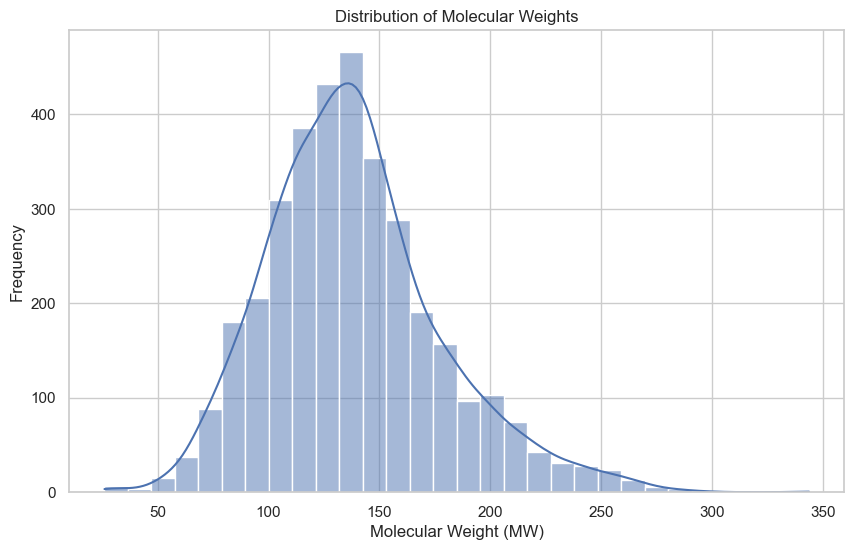

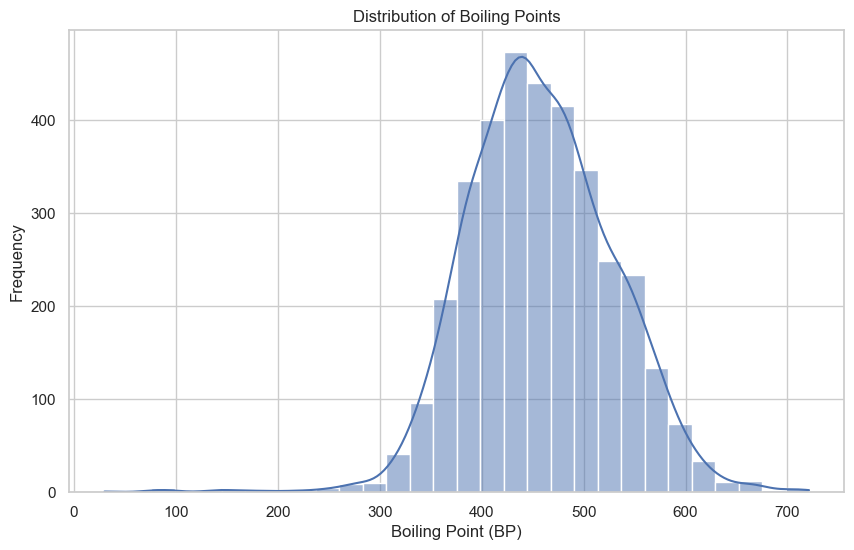

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure seaborn styles are used for the plots
sns.set(style="whitegrid")

# 1. Distribution of Molecular Weights (MW)
plt.figure(figsize=(10, 6))
sns.histplot(CompoundData['MW'], bins=30, kde=True)
plt.title('Distribution of Molecular Weights')
plt.xlabel('Molecular Weight (MW)')
plt.ylabel('Frequency')
plt.show()

# 2. Distribution of Boiling Points (BP)
plt.figure(figsize=(10, 6))
sns.histplot(CompoundData['BP'], bins=30, kde=True)
plt.title('Distribution of Boiling Points')
plt.xlabel('Boiling Point (BP)')
plt.ylabel('Frequency')
plt.show()

**Figure description.** Two separate histograms show frequency on the vertical axis. Molecular weight spans roughly 26–344 g/mol; boiling point spans roughly 30–721 K, with most observations concentrated away from the extremes.

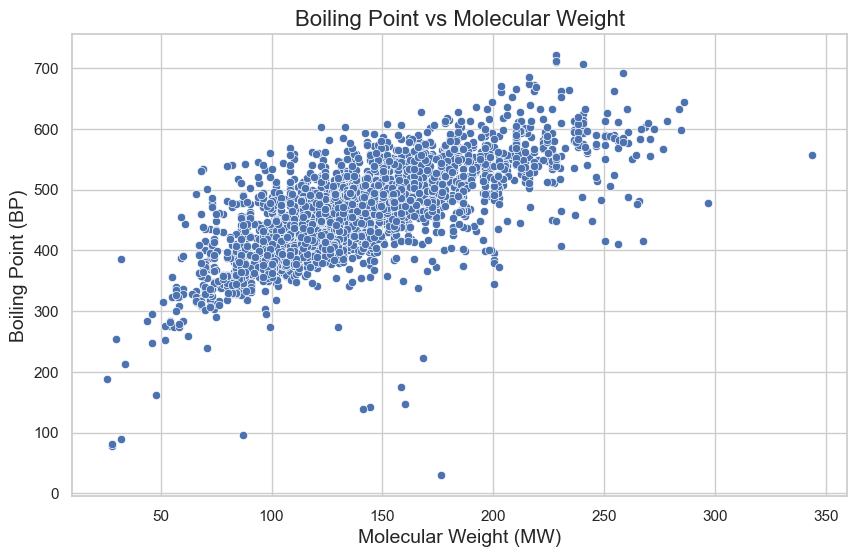

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure seaborn styles are applied
sns.set(style="whitegrid")

# Filter the CompoundData to exclude rows with missing values in 'BP' or 'MW'
filtered_data = CompoundData.dropna(subset=['BP', 'MW'])

# Create the scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x='MW', y='BP', data=filtered_data)

# Add titles and labels
plt.title('Boiling Point vs Molecular Weight', fontsize=16)
plt.xlabel('Molecular Weight (MW)', fontsize=14)
plt.ylabel('Boiling Point (BP)', fontsize=14)

# Show the plot
plt.show()


**Figure description.** A scatter plot places molecular weight on the horizontal axis and boiling point on the vertical axis. The cloud rises from lower left to upper right, while substantial vertical spread remains at similar molecular weights.

In [ ]:
# RDKit represents molecules and computes chemical features. It is already installed by environment.yml.
%pip install rdkit

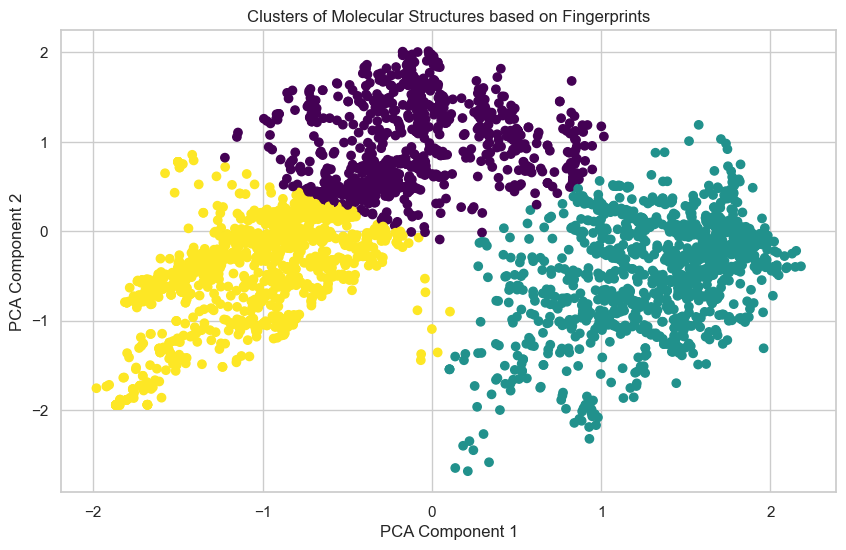

In [25]:
#https://github.com/rdkit/rdkit/tree/master/Docs/Notebooks

from rdkit import Chem
from rdkit.Chem import rdFingerprintGenerator
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Generate molecular fingerprints
fingerprints = []
for smiles in CompoundData['SMILES'].dropna():
    mol = Chem.MolFromSmiles(smiles)
    mg = rdFingerprintGenerator.GetMorganGenerator(radius = 2)
    fp = mg.GetFingerprint(mol)
    fingerprints.append(fp)

# Perform PCA for dimensionality reduction
pca = PCA(n_components=2)
fingerprints_2d = pca.fit_transform(fingerprints)

# Perform KMeans clustering
kmeans = KMeans(n_clusters=3)
labels = kmeans.fit_predict(fingerprints_2d)

# Visualize clusters in 2D
plt.figure(figsize=(10, 6))
plt.scatter(fingerprints_2d[:, 0], fingerprints_2d[:, 1], c=labels, cmap='viridis')
plt.title('Clusters of Molecular Structures based on Fingerprints')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.show()


**Figure description.** A two-dimensional scatter plot shows one molecule per point on two reduced representation components. Colors indicate assigned cluster labels; separated point clouds represent groups with similar structural fingerprints.